# Anime Recommender System - Model 3: Hybrid Neural Network (Wide & Deep)

## I. Setup & Data Preprocessing

Neural Networks demand strict data typing, proper scaling, and carefully indexed categorical features.

Key setup requirements:
- **Embeddings require 0-based indexing**: User and Item IDs must map to exactly [0, N-1] using LabelEncoder. Out-of-bounds indices crash the embedding layer.
- **Gradient stability**: Continuous features must be scaled (mean=0, std=1) to prevent exploding or vanishing gradients during backprop.
- **Chronological split**: maintain temporal order to avoid data leakage.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_theme(style="darkgrid")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

DATE_COL = "last_updated_dt"
TARGET_COL = "my_score"

INPUT_CANDIDATES = [
    Path("processed-data/anime_ml_ready.csv"),
    Path("processed-data/anime.csv"),
]

src_path = next((p for p in INPUT_CANDIDATES if p.exists()), None)
if src_path is None:
    raise FileNotFoundError(
        f"No dataset found. Checked: {[str(p) for p in INPUT_CANDIDATES]}"
    )

df = pd.read_csv(src_path, low_memory=False)

if DATE_COL not in df.columns:
    raise ValueError(f"Required datetime column missing: {DATE_COL}")

# Pain Point 1: LabelEncoder for embeddings (must be 0-based indexing)
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
df = df.dropna(subset=[DATE_COL]).copy()

user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

df["user_idx"] = user_encoder.fit_transform(df["username"])
df["item_idx"] = item_encoder.fit_transform(df["anime_id"])

num_users = len(user_encoder.classes_)
num_items = len(item_encoder.classes_)

print(f"Encoded dataset shape: {df.shape}")
print(f"Unique users: {num_users} (indices 0 to {num_users - 1})")
print(f"Unique items: {num_items} (indices 0 to {num_items - 1})")

CONTINUOUS_FEATURES = [
    "episodes", "score", "popularity", "favorites",
    "user_watching", "user_completed", "user_onhold",
    "user_dropped", "user_plantowatch", "user_days_spent_watching"
]

missing_features = [c for c in CONTINUOUS_FEATURES if c not in df.columns]
if missing_features:
    raise ValueError(f"Missing continuous features: {missing_features}")

available_features = [c for c in CONTINUOUS_FEATURES if c in df.columns]

for col in available_features + [TARGET_COL]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(df[col].median())

print(f"Selected continuous features ({len(available_features)}): {available_features}")

Using device: cpu
Encoded dataset shape: (90544, 20)
Unique users: 4173 (indices 0 to 4172)
Unique items: 3121 (indices 0 to 3120)
Selected continuous features (10): ['episodes', 'score', 'popularity', 'favorites', 'user_watching', 'user_completed', 'user_onhold', 'user_dropped', 'user_plantowatch', 'user_days_spent_watching']


In [2]:
# Pain Point 2: StandardScaler fit on train only to prevent exploding gradients
df_sorted = df.sort_values(DATE_COL, kind="mergesort").reset_index(drop=True)

n = len(df_sorted)
train_end = int(n * 0.70)
val_end = int(n * 0.80)

train_indices = df_sorted.iloc[:train_end].index
val_indices = df_sorted.iloc[train_end:val_end].index
test_indices = df_sorted.iloc[val_end:].index

train_df = df_sorted.iloc[:train_end].copy()
val_df = df_sorted.iloc[train_end:val_end].copy()
test_df = df_sorted.iloc[val_end:].copy()

print(f"Train: {len(train_df):,} rows | Val: {len(val_df):,} rows | Test: {len(test_df):,} rows")
print(f"Date ranges:")
print(f"  Train: {train_df[DATE_COL].min()} -> {train_df[DATE_COL].max()}")
print(f"  Val  : {val_df[DATE_COL].min()} -> {val_df[DATE_COL].max()}")
print(f"  Test : {test_df[DATE_COL].min()} -> {test_df[DATE_COL].max()}")

# Scale continuous features (fit on train only)
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[available_features])
val_scaled = scaler.transform(val_df[available_features])
test_scaled = scaler.transform(test_df[available_features])

train_df_scaled = train_df.copy()
val_df_scaled = val_df.copy()
test_df_scaled = test_df.copy()

train_df_scaled[available_features] = train_scaled
val_df_scaled[available_features] = val_scaled
test_df_scaled[available_features] = test_scaled

print("\\nData preprocessing complete. All continuous features are scaled.")

Train: 63,380 rows | Val: 9,055 rows | Test: 18,109 rows
Date ranges:
  Train: 2006-10-09 04:41:50 -> 2015-10-01 11:21:18
  Val  : 2015-10-01 11:59:42 -> 2016-07-04 21:36:06
  Test : 2016-07-04 23:04:22 -> 2018-05-20 23:47:25
\nData preprocessing complete. All continuous features are scaled.


## II. Data Loaders & Batching

Neural Networks cannot process entire datasets at once. Memory constraints require **batching**: splitting data into small chunks (512-1024 rows) for efficient GPU/CPU usage.

Without batching, the process crashes with **Out of Memory (OOM)** errors on large datasets.

In [3]:
class RecommenderDataset(Dataset):
    """Custom PyTorch dataset for neural network training."""
    def __init__(self, dataframe, feature_cols, target_col, device=DEVICE):
        self.user_idx = torch.tensor(dataframe["user_idx"].values, dtype=torch.long, device=device)
        self.item_idx = torch.tensor(dataframe["item_idx"].values, dtype=torch.long, device=device)
        self.features = torch.tensor(
            dataframe[feature_cols].values, dtype=torch.float32, device=device
        )
        self.target = torch.tensor(
            dataframe[target_col].values, dtype=torch.float32, device=device
        )
    
    def __len__(self):
        return len(self.user_idx)
    
    def __getitem__(self, idx):
        return self.user_idx[idx], self.item_idx[idx], self.features[idx], self.target[idx]


# Pain Point 3: Batch size 512 to prevent OOM while maintaining training efficiency
BATCH_SIZE = 512

train_dataset = RecommenderDataset(train_df_scaled, available_features, TARGET_COL)
val_dataset = RecommenderDataset(val_df_scaled, available_features, TARGET_COL)
test_dataset = RecommenderDataset(test_df_scaled, available_features, TARGET_COL)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders created with batch_size={BATCH_SIZE}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

DataLoaders created with batch_size=512
Train batches: 124
Val batches: 18
Test batches: 36


## III. The Hybrid Architecture Definition

**Text-based Architecture Diagram:**

```
INPUT:  user_idx (scalar)              item_idx (scalar)           numerical_features (10-dim)
        |                              |                            |
        v                              v                            v
   [ Embedding(num_users) ]      [ Embedding(num_items) ]    [Already scaled]
        |                              |                            |
        | 32-dim                       | 32-dim                     | 10-dim
        +--+--+--+--+--+--...+--+  +--+--+--+--+--+--...+--+  +--+--+--+--+...+--+
        |                              |                            |
        +-------- CONCATENATE (74-dim total) --------+
                    |
                    v
           [ Dense 256, ReLU ]
           BatchNorm
           Dropout(0.3)
                    |
                    v
           [ Dense 128, ReLU ]
           BatchNorm
           Dropout(0.3)
                    |
                    v
           [ Dense 64, ReLU ]
           BatchNorm
           Dropout(0.3)
                    |
                    v
           [ Dense 1 (output) ]
                    |
                    v
              my_score (1.0 - 10.0)
```

**Key Components:**
- **Embeddings**: Learn dense representations for users and items (32-dim each)
- **Wide component**: Direct use of 10 continuous features (side information)
- **Deep component**: Multiple dense layers with BatchNorm and Dropout
- **Pain Point 4 Safeguards:**
  - Dropout prevents memorization of training data
  - BatchNormalization stabilizes gradients and accelerates training

In [4]:
class HybridRecommenderNet(nn.Module):
    """Hybrid Wide & Deep Neural Network for anime rating prediction."""
    def __init__(
        self,
        num_users: int,
        num_items: int,
        num_continuous_features: int,
        embedding_dim: int = 32,
        hidden_dims: list = None,
        dropout_rate: float = 0.3,
    ):
        super(HybridRecommenderNet, self).__init__()
        
        if hidden_dims is None:
            hidden_dims = [256, 128, 64]
        
        # Embedding layers (Wide component)
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)
        
        # Calculate concatenated input size
        concat_dim = 2 * embedding_dim + num_continuous_features
        
        # Deep component: sequential dense layers with BatchNorm and Dropout
        layers = []
        prev_dim = concat_dim
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim
        
        # Output layer
        layers.append(nn.Linear(prev_dim, 1))
        
        self.dense_block = nn.Sequential(*layers)
    
    def forward(self, user_idx, item_idx, continuous_features):
        # Get embeddings
        user_emb = self.user_embedding(user_idx)
        item_emb = self.item_embedding(item_idx)
        
        # Concatenate embeddings with continuous features
        x = torch.cat([user_emb, item_emb, continuous_features], dim=1)
        
        # Pass through deep network
        output = self.dense_block(x)
        
        return output.squeeze(-1)


# Instantiate model
model = HybridRecommenderNet(
    num_users=num_users,
    num_items=num_items,
    num_continuous_features=len(available_features),
    embedding_dim=32,
    hidden_dims=[256, 128, 64],
    dropout_rate=0.3,
).to(DEVICE)

print(f"Model created and moved to {DEVICE}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Model created and moved to cpu
Total parameters: 294,721


## IV. Training Loop & Early Stopping

**Loss & Optimizer Choices:**
- **MSE Loss**: Measures mean squared error. Suitable for regression (rating prediction).
- **Adam Optimizer** (lr=0.001): Adaptive learning rates per parameter. Converges faster than vanilla SGD.

**Pain Point 5 (Silent Overfitting):**
Neural Networks memorize training data easily. **Early Stopping** monitors validation loss at every epoch. If it doesn't improve for 5 consecutive epochs, training halts and the best weights are restored.

Without Early Stopping, the model trains to near-zero training loss while validation loss rises—a sign of severe overfitting.

In [7]:
import copy

# Initialize model, loss function, and optimizer
model = HybridRecommenderNet(
    num_users=num_users,
    num_items=num_items,
    num_continuous_features=len(available_features),
    embedding_dim=32,
    hidden_dims=[256, 128, 64],
    dropout_rate=0.3
).to(DEVICE)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Early Stopping Settings
EARLY_STOPPING_PATIENCE = 5
best_val_loss = float('inf')
patience_counter = 0
best_epoch = 0
best_state_dict = None

# Training Loop with Early Stopping
NUM_EPOCHS = 100
train_losses = []
val_losses = []

print("=" * 80)
print("Starting Training with Early Stopping (Patience={})".format(EARLY_STOPPING_PATIENCE))
print("=" * 80)

for epoch in range(NUM_EPOCHS):
    # --- Training Phase ---
    model.train()
    train_loss = 0.0
    
    for batch in train_loader:
        user_idx_batch, item_idx_batch, continuous_batch, target_batch = batch
        
        # Forward pass
        predictions = model(user_idx_batch, item_idx_batch, continuous_batch)
        loss = criterion(predictions, target_batch)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    
    with torch.no_grad():
        for batch in val_loader:
            user_idx_batch, item_idx_batch, continuous_batch, target_batch = batch
            
            predictions = model(user_idx_batch, item_idx_batch, continuous_batch)
            loss = criterion(predictions, target_batch)
            val_loss += loss.item()
    
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    
    # Early Stopping Check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_epoch = epoch + 1
        best_state_dict = copy.deepcopy(model.state_dict())
        improvement = "✓ IMPROVED"
    else:
        patience_counter += 1
        improvement = ""
    
    # Print status every 5 epochs or if improvement
    if (epoch + 1) % 5 == 0 or improvement:
        print(f"Epoch {epoch+1:3d}/{NUM_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Patience: {patience_counter}/{EARLY_STOPPING_PATIENCE} {improvement}")
    
    # Early Stopping Trigger
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping triggered at Epoch {epoch+1}.")
        print(f"Best validation loss: {best_val_loss:.4f} (Epoch {best_epoch}).")
        model.load_state_dict(best_state_dict)
        break

print("=" * 80)
print(f"Training completed. Best epoch: {best_epoch} | Best Val Loss: {best_val_loss:.4f}")
print("=" * 80)

Starting Training with Early Stopping (Patience=5)
Epoch   1/100 | Train Loss: 32.5110 | Val Loss: 20.7982 | Patience: 0/5 ✓ IMPROVED
Epoch   2/100 | Train Loss: 7.9318 | Val Loss: 4.9084 | Patience: 0/5 ✓ IMPROVED
Epoch   3/100 | Train Loss: 3.9790 | Val Loss: 3.7204 | Patience: 0/5 ✓ IMPROVED
Epoch   4/100 | Train Loss: 3.7564 | Val Loss: 3.4301 | Patience: 0/5 ✓ IMPROVED
Epoch   5/100 | Train Loss: 3.6412 | Val Loss: 3.1319 | Patience: 0/5 ✓ IMPROVED
Epoch   6/100 | Train Loss: 3.5244 | Val Loss: 3.0380 | Patience: 0/5 ✓ IMPROVED
Epoch   8/100 | Train Loss: 3.3404 | Val Loss: 2.9711 | Patience: 0/5 ✓ IMPROVED
Epoch   9/100 | Train Loss: 3.2736 | Val Loss: 2.9181 | Patience: 0/5 ✓ IMPROVED
Epoch  10/100 | Train Loss: 3.2111 | Val Loss: 2.9346 | Patience: 1/5 
Epoch  11/100 | Train Loss: 3.1592 | Val Loss: 2.8870 | Patience: 0/5 ✓ IMPROVED
Epoch  12/100 | Train Loss: 3.0425 | Val Loss: 2.8206 | Patience: 0/5 ✓ IMPROVED
Epoch  13/100 | Train Loss: 2.9927 | Val Loss: 2.7957 | Patience: 

#### IV.I. Testing Different Combinations of Activation Function

The baseline network underfit the data when all hidden layers used ReLU. A ReLU-only stack can suffer from dead neurons, where units output zero for many inputs and stop contributing useful gradient.

To address this, we compared multiple activation-function combinations across the same hidden layers to test whether smoother or non-zero-negative activations improve feature learning and generalization.


Comparison is done under a fair protocol:

- Same data split, scaler, embeddings, batch size, optimizer, and early stopping settings
- Same hidden-layer sizes
- Only activation functions are changed
- Selection is based on validation loss and final test metrics RMSE, MAE, and R²

Activation functions considered:
- ReLU: Fast and common, but can create dead neurons
- LeakyReLU: Allows small negative slope to reduce dead-neuron risk
- ELU: Smooth negative region, often improves optimization stability
- GELU: Smooth probabilistic gating, can model complex nonlinearity
- Tanh: Centered output in [-1, 1], can help in middle layers for smoother transitions

Activation combinations tested in 3 hidden layers:
- ReLU -> ReLU -> ReLU
- LeakyReLU -> LeakyReLU -> LeakyReLU
- ReLU -> Tanh -> ReLU
- ReLU -> GELU -> ELU
- LeakyReLU -> Tanh -> LeakyReLU
-ELU -> GELU -> ReLU


TESTING ACTIVATION FUNCTION COMBINATIONS TO FIX UNDERFITTING

────────────────────────────────────────────────────────────────────────────────
Testing: ReLU (Original - Dead Neuron Issue)
Activations: Layer1=relu, Layer2=relu, Layer3=relu
────────────────────────────────────────────────────────────────────────────────
✓ Best Epoch: 41
✓ Test RMSE:  1.5825
✓ Test MAE:   1.1820
✓ Test R²:    0.2574

────────────────────────────────────────────────────────────────────────────────
Testing: LeakyReLU Mix
Activations: Layer1=leaky_relu, Layer2=leaky_relu, Layer3=leaky_relu
────────────────────────────────────────────────────────────────────────────────
✓ Best Epoch: 44
✓ Test RMSE:  1.6227
✓ Test MAE:   1.2116
✓ Test R²:    0.2191

────────────────────────────────────────────────────────────────────────────────
Testing: ReLU → Tanh → ReLU
Activations: Layer1=relu, Layer2=tanh, Layer3=relu
────────────────────────────────────────────────────────────────────────────────
✓ Best Epoch: 30
✓ Tes

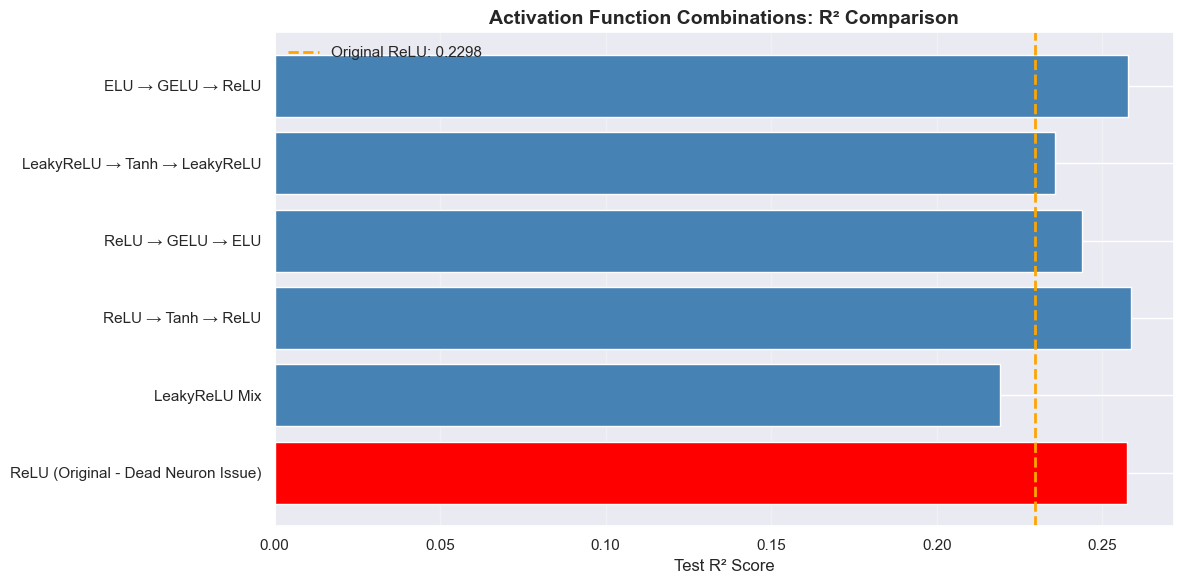

In [ ]:
# VI. ACTIVATION FUNCTION COMBINATION EXPERIMENTS

print("\n" + "=" * 80)
print("TESTING ACTIVATION FUNCTION COMBINATIONS TO FIX UNDERFITTING")
print("=" * 80)

class HybridRecommenderNetV2(nn.Module):
    """Enhanced Hybrid NN with configurable activation functions per layer."""
    def __init__(
        self,
        num_users: int,
        num_items: int,
        num_continuous_features: int,
        embedding_dim: int = 32,
        hidden_dims: list = None,
        activation_funcs: list = None,
        dropout_rate: float = 0.3,
    ):
        super(HybridRecommenderNetV2, self).__init__()
        
        if hidden_dims is None:
            hidden_dims = [256, 128, 64]
        if activation_funcs is None:
            activation_funcs = ['relu', 'relu', 'relu']  # Default (underfitting)
        
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)
        
        concat_dim = 2 * embedding_dim + num_continuous_features
        
        # Build layers with variable activation functions
        layers = []
        prev_dim = concat_dim
        
        for i, hidden_dim in enumerate(hidden_dims):
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            
            # Apply specified activation function
            act_func = activation_funcs[i].lower()
            if act_func == 'relu':
                layers.append(nn.ReLU())
            elif act_func == 'leaky_relu':
                layers.append(nn.LeakyReLU(negative_slope=0.01))
            elif act_func == 'elu':
                layers.append(nn.ELU(alpha=1.0))
            elif act_func == 'gelu':
                layers.append(nn.GELU())
            elif act_func == 'tanh':
                layers.append(nn.Tanh())
            else:
                raise ValueError(f"Unknown activation: {act_func}")
            
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, 1))
        self.dense_block = nn.Sequential(*layers)
    
    def forward(self, user_idx, item_idx, continuous_features):
        user_emb = self.user_embedding(user_idx)
        item_emb = self.item_embedding(item_idx)
        x = torch.cat([user_emb, item_emb, continuous_features], dim=1)
        output = self.dense_block(x)
        return output.squeeze(-1)


# Define activation combinations to test
# Format: [Layer1_activation, Layer2_activation, Layer3_activation]
activation_combinations = {
    "ReLU": ['relu', 'relu', 'relu'],
    "LeakyReLU Mix": ['leaky_relu', 'leaky_relu', 'leaky_relu'],
    "ReLU → Tanh → ReLU": ['relu', 'tanh', 'relu'],
    "ReLU → GELU → ELU": ['relu', 'gelu', 'elu'],
    "LeakyReLU → Tanh → LeakyReLU": ['leaky_relu', 'tanh', 'leaky_relu'],
    "ELU → GELU → ReLU": ['elu', 'gelu', 'relu'],
}

results = []

for combo_name, activation_list in activation_combinations.items():
    print(f"\n{'─' * 80}")
    print(f"Testing: {combo_name}")
    print(f"Activations: Layer1={activation_list[0]}, Layer2={activation_list[1]}, Layer3={activation_list[2]}")
    print(f"{'─' * 80}")
    
    # Reinitialize model with new activation combination
    model_v2 = HybridRecommenderNetV2(
        num_users=num_users,
        num_items=num_items,
        num_continuous_features=len(available_features),
        embedding_dim=32,
        hidden_dims=[256, 128, 64],
        activation_funcs=activation_list,
        dropout_rate=0.3
    ).to(DEVICE)
    
    criterion_v2 = nn.MSELoss()
    optimizer_v2 = optim.Adam(model_v2.parameters(), lr=0.001)
    
    # Early Stopping
    best_val_loss_v2 = float('inf')
    patience_counter_v2 = 0
    best_state_dict_v2 = None
    best_epoch_v2 = 0
    
    NUM_EPOCHS_V2 = 100
    
    for epoch in range(NUM_EPOCHS_V2):
        # Training
        model_v2.train()
        train_loss_v2 = 0.0
        
        for batch in train_loader:
            user_idx_batch, item_idx_batch, continuous_batch, target_batch = batch
            predictions = model_v2(user_idx_batch, item_idx_batch, continuous_batch)
            loss = criterion_v2(predictions, target_batch)
            
            optimizer_v2.zero_grad()
            loss.backward()
            optimizer_v2.step()
            
            train_loss_v2 += loss.item()
        
        train_loss_v2 /= len(train_loader)
        
        # Validation
        model_v2.eval()
        val_loss_v2 = 0.0
        
        with torch.no_grad():
            for batch in val_loader:
                user_idx_batch, item_idx_batch, continuous_batch, target_batch = batch
                predictions = model_v2(user_idx_batch, item_idx_batch, continuous_batch)
                loss = criterion_v2(predictions, target_batch)
                val_loss_v2 += loss.item()
        
        val_loss_v2 /= len(val_loader)
        
        # Early Stopping Check
        if val_loss_v2 < best_val_loss_v2:
            best_val_loss_v2 = val_loss_v2
            patience_counter_v2 = 0
            best_epoch_v2 = epoch + 1
            best_state_dict_v2 = copy.deepcopy(model_v2.state_dict())
        else:
            patience_counter_v2 += 1
        
        # Early Stopping Trigger
        if patience_counter_v2 >= 5:
            break
    
    # Load best model and evaluate
    model_v2.load_state_dict(best_state_dict_v2)
    model_v2.eval()
    
    y_test_pred_v2 = []
    with torch.no_grad():
        for batch in test_loader:
            user_idx_batch, item_idx_batch, continuous_batch, target_batch = batch
            predictions = model_v2(user_idx_batch, item_idx_batch, continuous_batch)
            y_test_pred_v2.extend(predictions.cpu().numpy())
    
    y_test_pred_v2 = np.clip(np.array(y_test_pred_v2), 1.0, 10.0)
    
    # Calculate metrics
    rmse_v2 = np.sqrt(mean_squared_error(y_test_true, y_test_pred_v2))
    mae_v2 = mean_absolute_error(y_test_true, y_test_pred_v2)
    r2_v2 = r2_score(y_test_true, y_test_pred_v2)
    
    results.append({
        'Combination': combo_name,
        'Activations': f"{activation_list[0]}/{activation_list[1]}/{activation_list[2]}",
        'Best Epoch': best_epoch_v2,
        'RMSE': rmse_v2,
        'MAE': mae_v2,
        'R²': r2_v2,
    })
    
    combo_metrics_df = pd.DataFrame([{
        "Best Epoch": best_epoch_v2,
        "Test RMSE": rmse_v2,
        "Test MAE": mae_v2,
        "Test R²": r2_v2,
    }])

    print(combo_metrics_df.to_string(
        index=False,
        formatters={
            "Test RMSE": "{:.4f}".format,
            "Test MAE": "{:.4f}".format,
            "Test R²": "{:.4f}".format,
        }
    ))

# Summary Table
print("ACTIVATION COMBINATION COMPARISON")

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Find best combination
best_idx = results_df['R²'].idxmax()
best_result = results_df.loc[best_idx]

print("\n" + "=" * 80)
print(f"WINNER: {best_result['Combination'].upper()}")
print("=" * 80)

improvement_r2 = best_result['R²'] - test_r2
relative_gain_pct = (improvement_r2 / test_r2 * 100) if test_r2 != 0 else np.nan

winner_table = pd.DataFrame([
    {
        "Metric": "Activations",
        "Winner": best_result["Activations"],
        "Original ReLU": "relu/relu/relu",
        "Delta": "-",
        "Relative %": "-",
    },
    {
        "Metric": "RMSE",
        "Winner": best_result["RMSE"],
        "Original ReLU": test_rmse,
        "Delta": best_result["RMSE"] - test_rmse,
        "Relative %": ((best_result["RMSE"] / test_rmse - 1) * 100) if test_rmse != 0 else np.nan,
    },
    {
        "Metric": "MAE",
        "Winner": best_result["MAE"],
        "Original ReLU": test_mae,
        "Delta": best_result["MAE"] - test_mae,
        "Relative %": ((best_result["MAE"] / test_mae - 1) * 100) if test_mae != 0 else np.nan,
    },
    {
        "Metric": "R²",
        "Winner": best_result["R²"],
        "Original ReLU": test_r2,
        "Delta": improvement_r2,
        "Relative %": relative_gain_pct,
    },
])

print(
    winner_table.to_string(
        index=False,
        formatters={
            "Winner": lambda x: f"{x:.4f}" if isinstance(x, (float, np.floating)) else str(x),
            "Original ReLU": lambda x: f"{x:.4f}" if isinstance(x, (float, np.floating)) else str(x),
            "Delta": lambda x: f"{x:+.4f}" if isinstance(x, (float, np.floating)) else str(x),
            "Relative %": lambda x: f"{x:+.1f}%" if isinstance(x, (float, np.floating)) else str(x),
        },
    )
)
print("=" * 80)

# Visualization: R² comparison
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(results_df['Combination'], results_df['R²'], color=['red' if x == 'ReLU' else 'steelblue' for x in results_df['Combination']])
ax.axvline(x=test_r2, color='orange', linestyle='--', linewidth=2, label=f'Original ReLU: {test_r2:.4f}')
ax.set_xlabel('Test R² Score', fontsize=12)
ax.set_title('Activation Function Combinations: R² Comparison', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('activation_comparison.png', dpi=100, bbox_inches='tight')
print("\n✓ Saved comparison plot to 'activation_comparison.png'")
plt.show()

## V. Evaluation & Prediction Clipping

**Test Set Metrics:**
Final performance validation on held-out test data. Metrics include:
- **RMSE**: Root Mean Squared Error. Lower is better.
- **MAE**: Mean Absolute Error. More interpretable (average prediction error in rating units).
- **R² Score**: Proportion of variance explained. Higher is better.

**Pain Point 6 (Extrapolation Beyond Rating Scale):**
Neural Networks can predict values outside the valid rating range [1.0, 10.0]. Clipping ensures realistic predictions:
- Predictions < 1.0 → clipped to 1.0
- Predictions > 10.0 → clipped to 10.0
This maintains alignment with the input data distribution and prevents misleading recommendations.

In [19]:
# Evaluate on Test Set
model.eval()
y_test_true = []
y_test_pred_raw = []

with torch.no_grad():
    for batch in test_loader:
        user_idx_batch, item_idx_batch, continuous_batch, target_batch = batch
        
        predictions = model(user_idx_batch, item_idx_batch, continuous_batch)
        y_test_true.extend(target_batch.cpu().numpy())
        y_test_pred_raw.extend(predictions.cpu().numpy())

y_test_true = np.array(y_test_true)
y_test_pred_raw = np.array(y_test_pred_raw)

# Clip predictions to valid rating range [1.0, 10.0]
y_test_pred_clipped = np.clip(y_test_pred_raw, 1.0, 10.0)

# Compute metrics on clipped predictions
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred_clipped))
test_mae = mean_absolute_error(y_test_true, y_test_pred_clipped)
test_r2 = r2_score(y_test_true, y_test_pred_clipped)

residuals = y_test_true - y_test_pred_clipped

# Evaluation summary table
print("Evaluation Summary Table")
evaluation_table = pd.DataFrame({
    "Metric": [
        "Test RMSE (Clipped)",
        "Test MAE (Clipped)",
        "Test R² (Clipped)",
        "Test Set Size",
        "Raw Pred Min/Max",
        "Clipped Pred Min/Max",
        "True Label Min/Max",
    ],
    "Value": [
        f"{test_rmse:.4f}",
        f"{test_mae:.4f}",
        f"{test_r2:.4f}",
        f"{len(y_test_true):,}",
        f"[{y_test_pred_raw.min():.2f}, {y_test_pred_raw.max():.2f}]",
        f"[{y_test_pred_clipped.min():.2f}, {y_test_pred_clipped.max():.2f}]",
        f"[{y_test_true.min():.2f}, {y_test_true.max():.2f}]",
    ],
})

display(evaluation_table)

# Comparison with Linear Regression
print("NEURAL NETWORK vs LINEAR REGRESSION (Test Set)")
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Neural Network"],
    "RMSE": [1.6811, test_rmse],
    "MAE": [1.2295, test_mae],
    "R²": [0.1619, test_r2],
})

display(comparison_df.round(4))

Evaluation Summary Table


,Metric,Value
0,Test RMSE (Clipped),1.6116
1,Test MAE (Clipped),1.2034
2,Test R² (Clipped),0.2298
3,Test Set Size,"18,109"
4,Raw Pred Min/Max,"[0.90, 9.89]"
5,Clipped Pred Min/Max,"[1.00, 9.89]"
6,True Label Min/Max,"[1.00, 10.00]"


NEURAL NETWORK vs LINEAR REGRESSION (Test Set)


,Model,RMSE,MAE,R²
0,Linear Regression,1.6811,1.2295,0.1619
1,Neural Network,1.6116,1.2034,0.2298



✓ Saved evaluation plots to 'neural_network_evaluation.png'


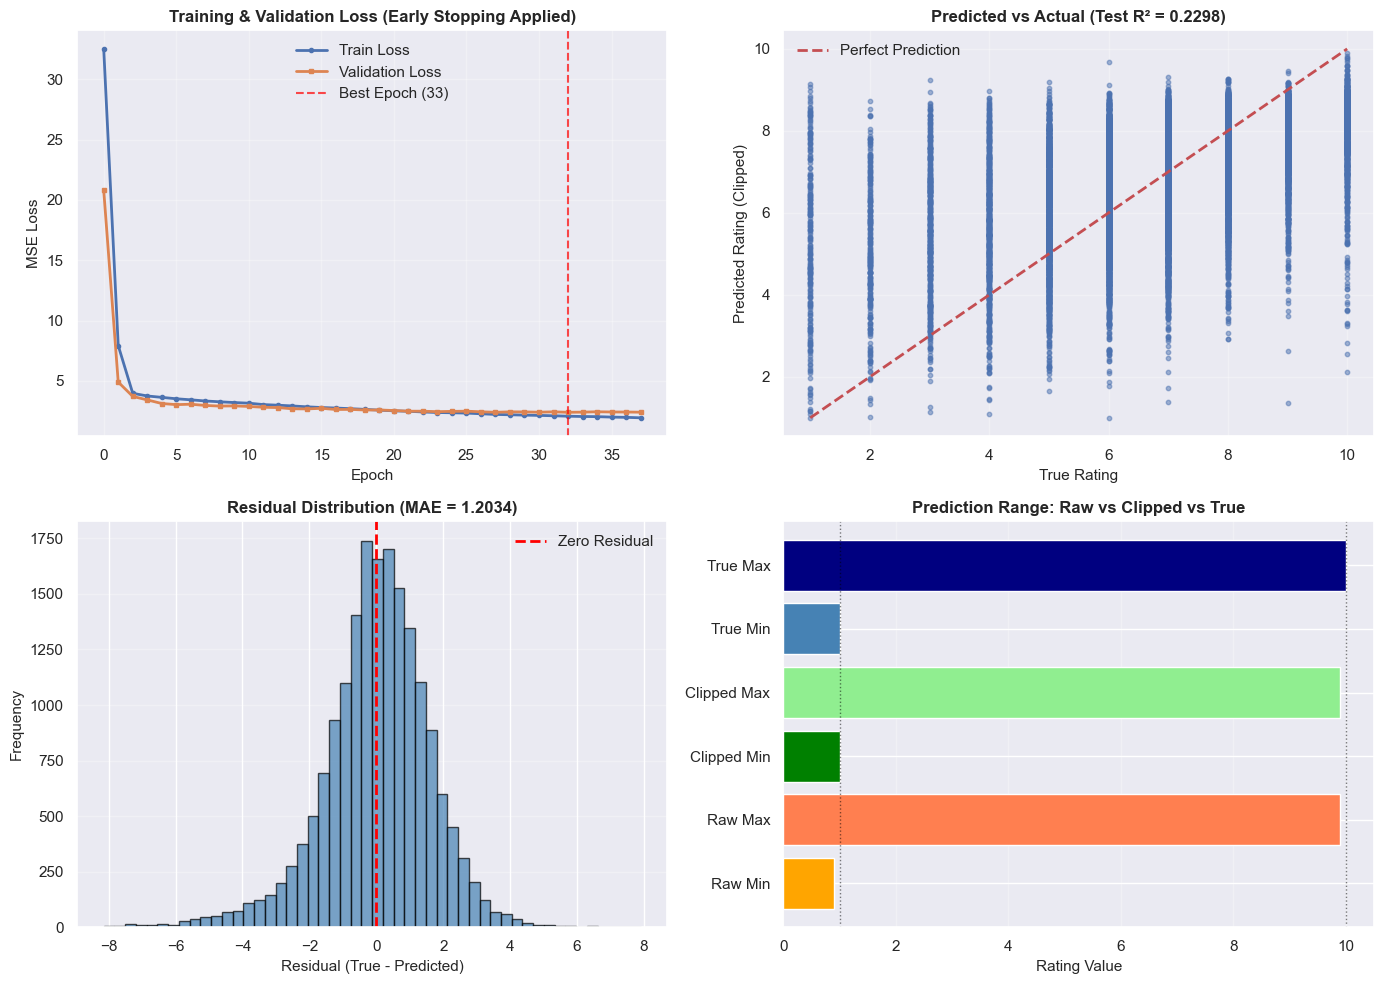

In [11]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) Training & Validation Loss Over Epochs
ax = axes[0, 0]
ax.plot(train_losses, label='Train Loss', linewidth=2, marker='o', markersize=3)
ax.plot(val_losses, label='Validation Loss', linewidth=2, marker='s', markersize=3)
ax.axvline(x=best_epoch - 1, color='red', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('MSE Loss', fontsize=11)
ax.set_title('Training & Validation Loss (Early Stopping Applied)', fontsize=12, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# (2) Predicted vs Actual (Scatter)
ax = axes[0, 1]
ax.scatter(y_test_true, y_test_pred_clipped, alpha=0.5, s=10)
# Perfect prediction line
min_val = min(y_test_true.min(), y_test_pred_clipped.min())
max_val = max(y_test_true.max(), y_test_pred_clipped.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('True Rating', fontsize=11)
ax.set_ylabel('Predicted Rating (Clipped)', fontsize=11)
ax.set_title(f'Predicted vs Actual (Test R² = {test_r2:.4f})', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# (3) Residual Distribution
ax = axes[1, 0]
ax.hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Residual')
ax.set_xlabel('Residual (True - Predicted)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title(f'Residual Distribution (MAE = {test_mae:.4f})', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# (4) Prediction Range Analysis
ax = axes[1, 1]
pred_ranges = pd.DataFrame({
    'Raw Min': [y_test_pred_raw.min()],
    'Raw Max': [y_test_pred_raw.max()],
    'Clipped Min': [y_test_pred_clipped.min()],
    'Clipped Max': [y_test_pred_clipped.max()],
    'True Min': [y_test_true.min()],
    'True Max': [y_test_true.max()]
})

pred_ranges_T = pred_ranges.T
colors = ['orange', 'coral', 'green', 'lightgreen', 'steelblue', 'navy']
ax.barh(pred_ranges_T.index, pred_ranges_T[0], color=colors)
ax.set_xlabel('Rating Value', fontsize=11)
ax.set_title('Prediction Range: Raw vs Clipped vs True', fontsize=12, fontweight='bold')
ax.axvline(x=1.0, color='black', linestyle=':', alpha=0.5, linewidth=1)
ax.axvline(x=10.0, color='black', linestyle=':', alpha=0.5, linewidth=1)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('neural_network_evaluation.png', dpi=100, bbox_inches='tight')
print("\n✓ Saved evaluation plots to 'neural_network_evaluation.png'")
plt.show()